{'fog': 637, 'rain': 698, 'snow': 752}
Всего изображений: 2087


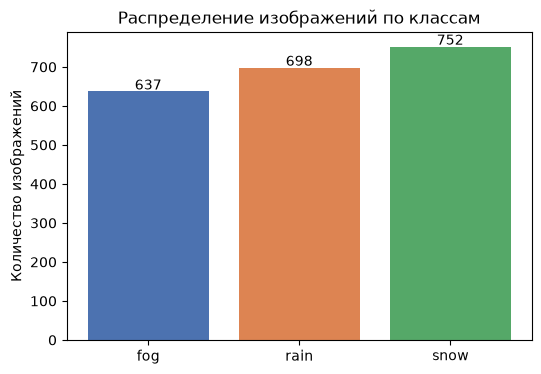

In [1]:
import os
import matplotlib.pyplot as plt

TRAIN_DATA_DIR = '../data/train/train'

# баланс классов и количество данных
classes = sorted(os.listdir(TRAIN_DATA_DIR))
counts = {}

for cls in classes:
    cls_dir = os.path.join(TRAIN_DATA_DIR, cls)
    n_images = len([f for f in os.listdir(cls_dir) if f.lower().endswith(('.png', 'jpg', '.jpeg'))])
    counts[cls] = n_images

print(counts)
print(f"Всего изображений: {sum(counts.values())}")

plt.figure(figsize=(6, 4))
plt.bar(counts.keys(), counts.values(), color=['#4C72B0', '#DD8452', '#55A868'])
plt.title("Распределение изображений по классам")
plt.ylabel("Количество изображений")
for i, (cls, n) in enumerate(counts.items()):
    plt.text(i, n + 5, str(n), ha='center')
plt.show()

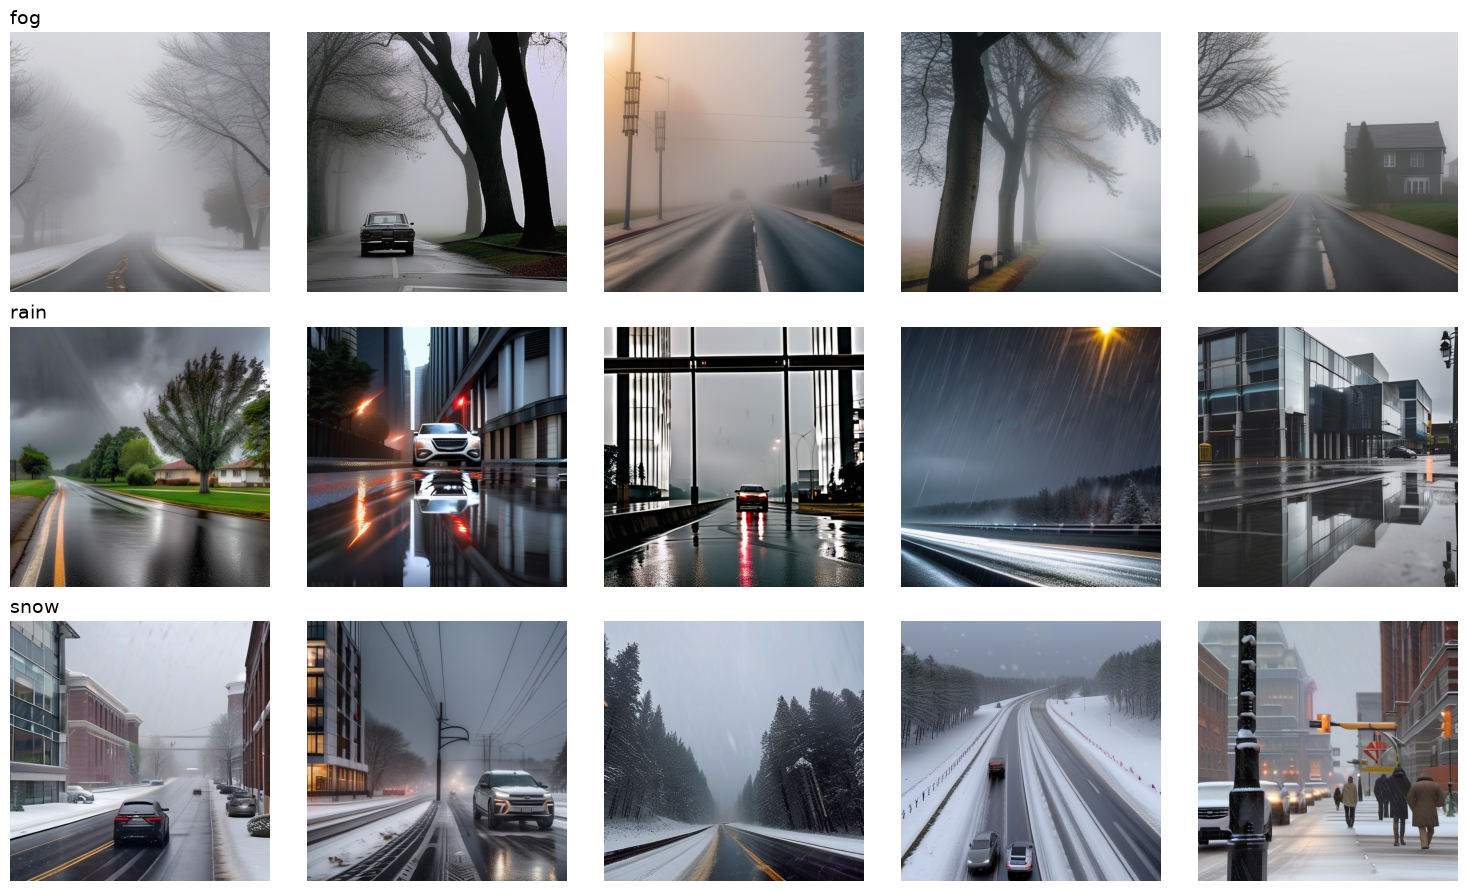

In [4]:
from PIL import Image
import random

# просмотр изображений
fig, axes = plt.subplots(3, 5, figsize=(15, 9))

for row, cls in enumerate(classes):
    cls_dir = os.path.join(TRAIN_DATA_DIR, cls)
    files = [f for f in os.listdir(cls_dir) if f.lower().endswith(('.png', 'jpg', '.jpeg'))]
    sample_files = random.sample(files, 5)

    for col, fname in enumerate(sample_files):
        img = Image.open(os.path.join(cls_dir, fname))
        axes[row, col].imshow(img)
        axes[row, col].axis('off')
        if col == 0:
            axes[row, col].set_ylabel(cls, fontsize=14)

    axes[row, 0].set_title(cls, fontsize=14, loc='left')

plt.tight_layout()
plt.show()

In [5]:
sizes = set()
modes = set()
bad_files = []

for cls in classes:
    cls_dir = os.path.join(TRAIN_DATA_DIR, cls)
    for fname in os.listdir(cls_dir):
        if not fname.lower().endswith(('.png', '.jpg', 'jpeg')):
            continue
        path = os.path.join(cls_dir, fname)
        try:
            img = Image.open(path)
            sizes.add(img.size)
            modes.add(img.mode)
        except Exception as e:
            bad_files.append((path, str(e)))

print("Уникальные размеры изображений:", sizes)
print("Уникальные цветовые режимы:", modes)
print(f"Повреждённых файлов: {len(bad_files)}")
for f, err in bad_files:
    print(f, err)

Уникальные размеры изображений: {(512, 512)}
Уникальные цветовые режимы: {'RGB'}
Повреждённых файлов: 0


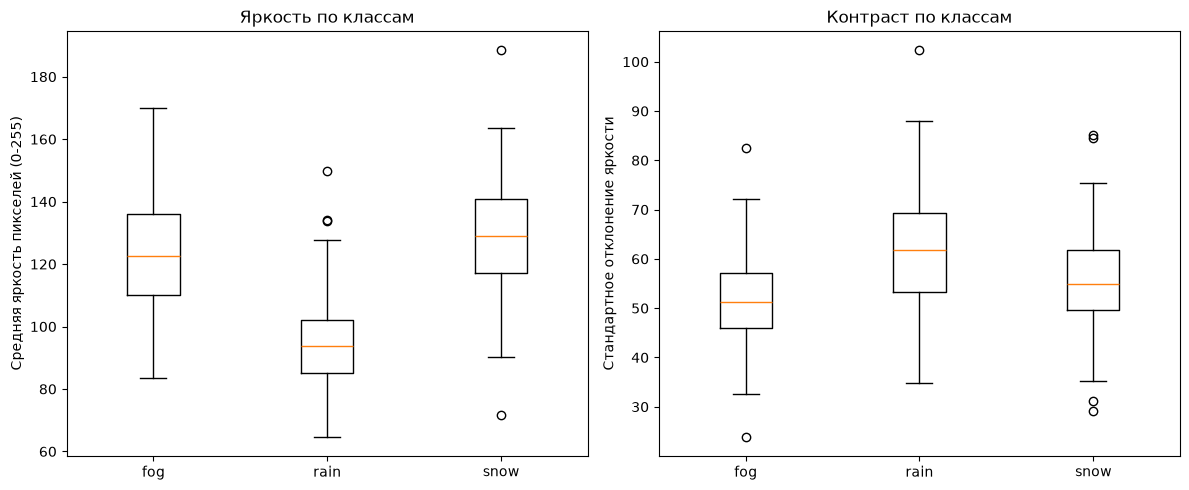

fog: яркость=123.8, контраст=51.6
rain: яркость=95.6, контраст=62.4
snow: яркость=128.4, контраст=55.7


In [7]:
import numpy as np

def compute_brightness_contrast(img):
    arr = np.array(img.convert('L'), dtype=np.float32)  # в градации серого
    brightness = arr.mean()
    contrast = arr.std()
    return brightness, contrast

# берём выборку изображений на класс, чтобы не считать по всему датасету (быстрее)
sample_size = 150

results = {cls: {'brightness': [], 'contrast': []} for cls in classes}

for cls in classes:
    cls_dir = os.path.join(TRAIN_DATA_DIR, cls)
    files = [f for f in os.listdir(cls_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    sample_files = random.sample(files, min(sample_size, len(files)))

    for fname in sample_files:
        img = Image.open(os.path.join(cls_dir, fname))
        b, c = compute_brightness_contrast(img)
        results[cls]['brightness'].append(b)
        results[cls]['contrast'].append(c)

# визуализация
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].boxplot([results[cls]['brightness'] for cls in classes], tick_labels=classes)
axes[0].set_title('Яркость по классам')
axes[0].set_ylabel('Средняя яркость пикселей (0-255)')

axes[1].boxplot([results[cls]['contrast'] for cls in classes], tick_labels=classes)
axes[1].set_title('Контраст по классам')
axes[1].set_ylabel('Стандартное отклонение яркости')

plt.tight_layout()
plt.show()

# числовая сводка
for cls in classes:
    b_mean = np.mean(results[cls]['brightness'])
    c_mean = np.mean(results[cls]['contrast'])
    print(f"{cls}: яркость={b_mean:.1f}, контраст={c_mean:.1f}")

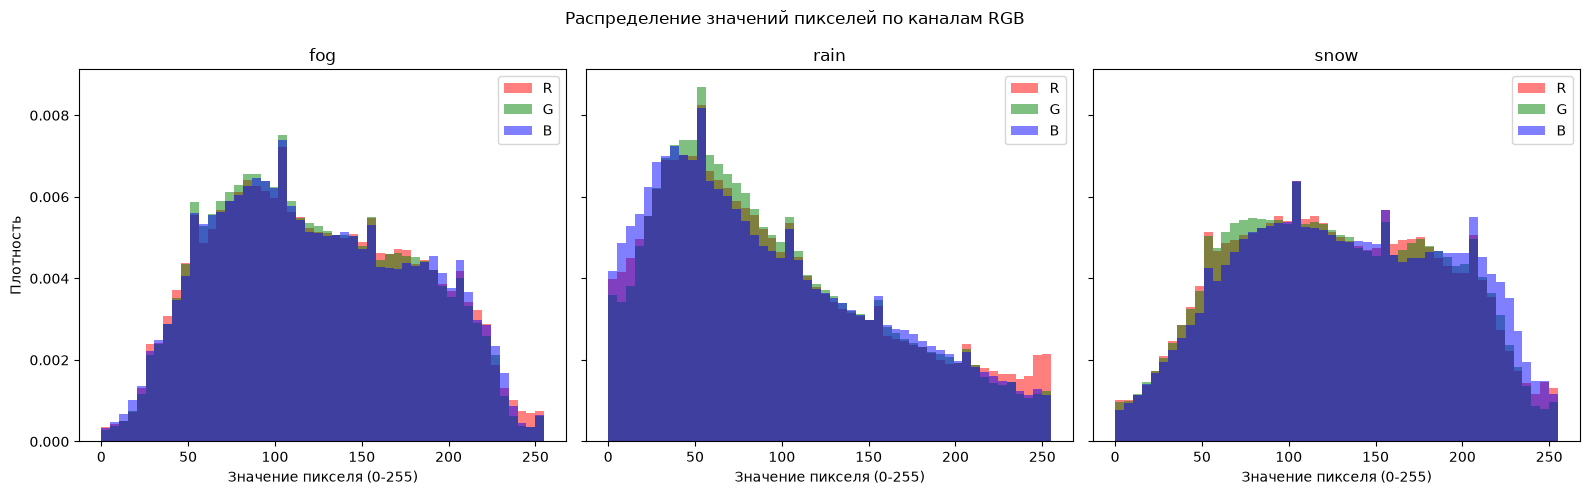

In [8]:
sample_size = 150
colors = ['red', 'green', 'blue']
channel_names = ['R', 'G', 'B']

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

for ax, cls in zip(axes, classes):
    cls_dir = os.path.join(TRAIN_DATA_DIR, cls)
    files = [f for f in os.listdir(cls_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    sample_files = random.sample(files, min(sample_size, len(files)))

    # накапливаем все пиксельные значения по каждому каналу
    channel_values = {0: [], 1: [], 2: []}

    for fname in sample_files:
        img = Image.open(os.path.join(cls_dir, fname)).convert('RGB')
        arr = np.array(img)
        for i in range(3):
            channel_values[i].append(arr[:, :, i].flatten())

    for i, color in enumerate(colors):
        values = np.concatenate(channel_values[i])
        ax.hist(values, bins=50, color=color, alpha=0.5, label=channel_names[i], density=True)

    ax.set_title(cls)
    ax.set_xlabel('Значение пикселя (0-255)')
    ax.legend()

axes[0].set_ylabel('Плотность')
plt.suptitle('Распределение значений пикселей по каналам RGB')
plt.tight_layout()
plt.show()